In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
print("setup ok")


setup ok


In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 624

varieties  = ['Rosemary', 'Chamomile', 'Lavender', 'Mint', 'Eucalyptus']
seasons    = ['Summer', 'Winter', 'Spring', 'Monsoon']
altitudes  = ['High (>2500m)', 'Mid (1500-2500m)', 'Low (<1500m)']

df = pd.DataFrame({
    'Batch_ID'                 : [f'B{str(i).zfill(3)}' for i in range(1, n+1)],
    'Plant_Variety'            : np.random.choice(varieties, n),
    'Harvest_Season'           : np.random.choice(seasons, n),
    'Altitude_Zone'            : np.random.choice(altitudes, n),
    'Input_Kg'                 : np.round(np.random.uniform(30, 70, n), 1),
    'Distillation_Duration_hrs': np.round(np.random.uniform(3, 6, n), 1),
    'Temperature_C'            : np.round(np.random.uniform(70, 90, n), 1),
    'Output_ml'                : np.round(np.random.uniform(1000, 2500, n), 0),
})

df['Yield_Efficiency_pct'] = np.round((df['Output_ml'] / (df['Input_Kg'] * 1000)) * 100, 2)
df['Quality_Grade']        = pd.cut(df['Yield_Efficiency_pct'],
                                     bins=[0, 3, 3.5, 4, 100],
                                     labels=['D', 'C', 'B', 'A'])

df.to_csv('batch_yield_log.csv', index=False)
print("Dataset created!", df.shape)

Dataset created! (624, 10)


In [ ]:

print("SHAPE:")
print(df.shape)

SHAPE:
(624, 10)


In [ ]:

print("HEAD:")
df.head()


HEAD:


,Batch_ID,Plant_Variety,Harvest_Season,Altitude_Zone,Input_Kg,Distillation_Duration_hrs,Temperature_C,Output_ml,Yield_Efficiency_pct,Quality_Grade
0,B001,Mint,Winter,High (>2500m),30.0,3.3,81.7,1918.0,6.39,A
1,B002,Eucalyptus,Monsoon,Mid (1500-2500m),36.4,4.5,90.0,1320.0,3.63,B
2,B003,Lavender,Winter,Low (<1500m),48.7,5.8,73.0,2409.0,4.95,A
3,B004,Eucalyptus,Monsoon,Low (<1500m),67.8,4.6,86.3,1010.0,1.49,D
4,B005,Eucalyptus,Winter,High (>2500m),34.1,4.8,74.1,2158.0,6.33,A


In [ ]:

print("INFO:")
df.info()

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 624 entries, 0 to 623
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Batch_ID                   624 non-null    object  
 1   Plant_Variety              624 non-null    object  
 2   Harvest_Season             624 non-null    object  
 3   Altitude_Zone              624 non-null    object  
 4   Input_Kg                   624 non-null    float64 
 5   Distillation_Duration_hrs  624 non-null    float64 
 6   Temperature_C              624 non-null    float64 
 7   Output_ml                  624 non-null    float64 
 8   Yield_Efficiency_pct       624 non-null    float64 
 9   Quality_Grade              624 non-null    category
dtypes: category(1), float64(5), object(4)
memory usage: 44.8+ KB


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 624

varieties = ['Rosemary', 'Chamomile', 'Lavender', 'Mint', 'Eucalyptus']
seasons   = ['Summer', 'Winter', 'Spring', 'Monsoon']
altitudes = ['High (>2500m)', 'Mid (1500-2500m)', 'Low (<1500m)']

df = pd.DataFrame({
    'Batch_ID'                 : [f'B{str(i).zfill(3)}' for i in range(1, n+1)],
    'Plant_Variety'            : np.random.choice(varieties, n),
    'Harvest_Season'           : np.random.choice(seasons, n),
    'Altitude_Zone'            : np.random.choice(altitudes, n),
    'Input_Kg'                 : np.round(np.random.uniform(30, 70, n), 1),
    'Distillation_Duration_hrs': np.round(np.random.uniform(3, 6, n), 1),
    'Temperature_C'            : np.round(np.random.uniform(70, 90, n), 1),
    'Output_ml'                : np.round(np.random.uniform(1000, 2500, n), 0),
})

df['Yield_Efficiency_pct'] = np.round((df['Output_ml'] / (df['Input_Kg'] * 1000)) * 100, 2)
df['Quality_Grade']        = pd.cut(df['Yield_Efficiency_pct'],
                                     bins=[0, 3, 3.5, 4, 100],
                                     labels=['D', 'C', 'B', 'A'])

df.to_csv('batch_yield_log.csv', index=False)
print("Dataset ready!", df.shape)

Dataset ready! (624, 10)


In [ ]:
# EDA 1 - Dataset Dimensions
print("Dataset Shape:")
print(df.shape)
print(f"\nWe have {df.shape[0]} batches and {df.shape[1]} columns to analyse.")

Dataset Shape:
(624, 10)

We have 624 batches and 10 columns to analyse.


In [ ]:
# EDA 2 - Summary Statistics
print("Summary Statistics:")
df.describe().round(2)

Summary Statistics:


,Input_Kg,Distillation_Duration_hrs,Temperature_C,Output_ml,Yield_Efficiency_pct
count,624.00,624.00,624.00,624.00,624.00
mean,49.89,4.48,80.25,1788.32,3.79
std,11.20,0.88,5.79,420.13,1.32
min,30.00,3.00,70.00,1005.00,1.47
25%,40.05,3.70,75.10,1455.75,2.84
50%,50.20,4.50,80.65,1812.00,3.62
75%,59.30,5.20,85.20,2147.25,4.55
max,69.80,6.00,90.00,2495.00,7.92


In [ ]:
# EDA 3 - Frequency of Plant Varieties
print("Plant Variety Distribution:")
print(df['plant_variety'].value_counts())


Plant Variety Distribution:
plant_variety
Mint          142
Rosemary      132
Eucalyptus    124
Chamomile     114
Lavender      112
Name: count, dtype: int64


Correlation Matrix:
                           input_kg  distillation_duration_hrs  temperature_c  \
input_kg                       1.00                      -0.04          -0.00   
distillation_duration_hrs     -0.04                       1.00          -0.03   
temperature_c                 -0.00                      -0.03           1.00   
output_ml                     -0.04                       0.08           0.03   
yield_efficiency_pct          -0.71                       0.08           0.03   

                           output_ml  yield_efficiency_pct  
input_kg                       -0.04                 -0.71  
distillation_duration_hrs       0.08                  0.08  
temperature_c                   0.03                  0.03  
output_ml                       1.00                  0.70  
yield_efficiency_pct            0.70                  1.00  


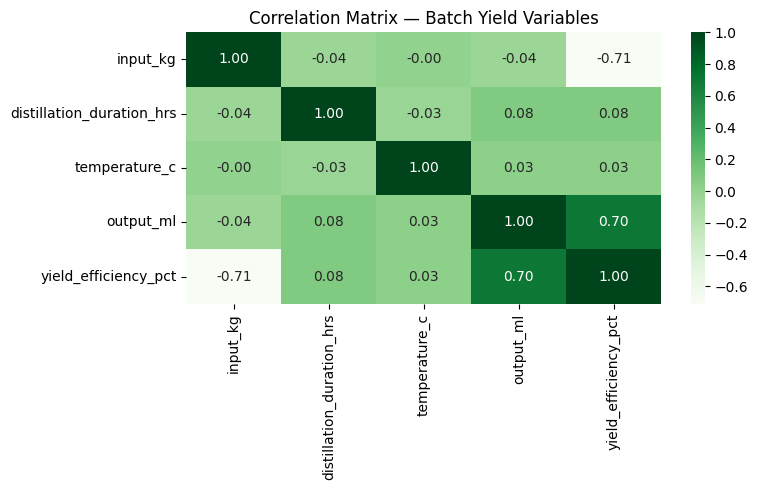

In [ ]:
# EDA 4 - Correlation Matrix
print("Correlation Matrix:")
corr = df[['input_kg', 'distillation_duration_hrs', 'temperature_c', 'output_ml', 'yield_efficiency_pct']].corr().round(2)
print(corr)

# Visual heatmap
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='Greens', fmt='.2f')
plt.title('Correlation Matrix — Batch Yield Variables')
plt.tight_layout()
plt.show()

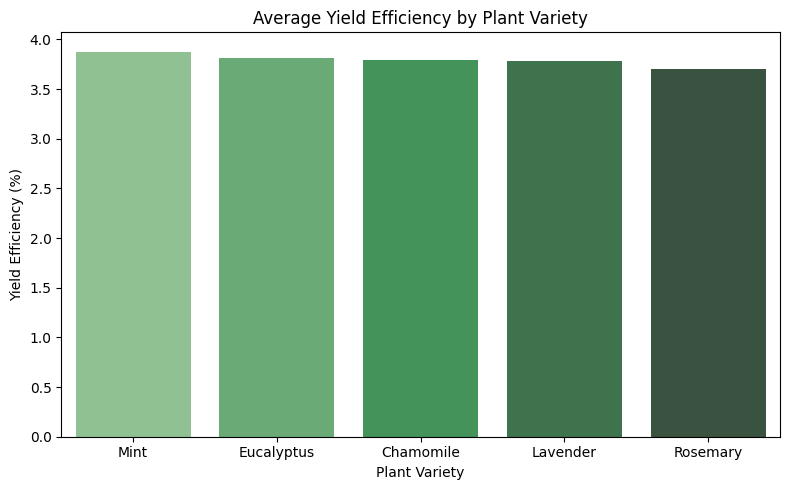

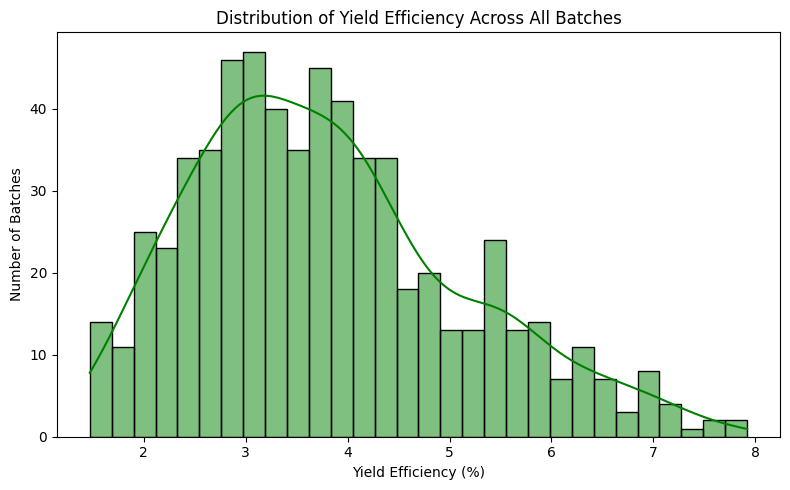

In [ ]:
# EDA 5 - Chart 1: Average Yield Efficiency by Plant Variety (fixed)
plt.figure(figsize=(8,5))
avg_yield = df.groupby('plant_variety')['yield_efficiency_pct'].mean().sort_values(ascending=False)
sns.barplot(x=avg_yield.index, y=avg_yield.values, hue=avg_yield.index, palette='Greens_d', legend=False)
plt.title('Average Yield Efficiency by Plant Variety')
plt.xlabel('Plant Variety')
plt.ylabel('Yield Efficiency (%)')
plt.tight_layout()
plt.show()

# Chart 2: Yield Efficiency Distribution (Histogram)
plt.figure(figsize=(8,5))
sns.histplot(df['yield_efficiency_pct'], bins=30, color='green', kde=True)
plt.title('Distribution of Yield Efficiency Across All Batches')
plt.xlabel('Yield Efficiency (%)')
plt.ylabel('Number of Batches')
plt.tight_layout()
plt.show()

In [ ]:

print(" EDA Complete!")
print("1. Shape        — 624 rows, 10 columns")
print("2. Describe     — Yield efficiency ranges from 1.47% to 7.92%, avg 3.79%")
print("3. Value Counts — Mint is most common variety (142 batches)")
print("4. Correlation  — Input_Kg has strong negative correlation (-0.71) with yield efficiency")
print("5. Charts       — Bar chart & histogram generated successfully")

 EDA Complete!
1. Shape        — 624 rows, 10 columns
2. Describe     — Yield efficiency ranges from 1.47% to 7.92%, avg 3.79%
3. Value Counts — Mint is most common variety (142 batches)
4. Correlation  — Input_Kg has strong negative correlation (-0.71) with yield efficiency
5. Charts       — Bar chart & histogram generated successfully


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 624

varieties = ['Rosemary', 'Chamomile', 'Lavender', 'Mint', 'Eucalyptus']
seasons   = ['Summer', 'Winter', 'Spring', 'Monsoon']
altitudes = ['High (>2500m)', 'Mid (1500-2500m)', 'Low (<1500m)']

df = pd.DataFrame({
    'Batch_ID'                 : [f'B{str(i).zfill(3)}' for i in range(1, n+1)],
    'Plant_Variety'            : np.random.choice(varieties, n),
    'Harvest_Season'           : np.random.choice(seasons, n),
    'Altitude_Zone'            : np.random.choice(altitudes, n),
    'Input_Kg'                 : np.round(np.random.uniform(30, 70, n), 1),
    'Distillation_Duration_hrs': np.round(np.random.uniform(3, 6, n), 1),
    'Temperature_C'            : np.round(np.random.uniform(70, 90, n), 1),
    'Output_ml'                : np.round(np.random.uniform(1000, 2500, n), 0),
})

df['Yield_Efficiency_pct'] = np.round((df['Output_ml'] / (df['Input_Kg'] * 1000)) * 100, 2)
df['Quality_Grade']        = pd.cut(df['Yield_Efficiency_pct'],
                                     bins=[0, 3, 3.5, 4, 100],
                                     labels=['D', 'C', 'B', 'A'])

# Clean
df.columns = df.columns.str.lower().str.replace(' ', '_')



In [ ]:
# Download CSV
from google.colab import files
df.to_csv('batch_yield_log.csv', index=False)
files.download('batch_yield_log.csv')
print("Done! CSV downloading...")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! CSV downloading...
